# Logistic Regression

In this notebook, we train Logistic Regression models to predict dry (0) or wet (1) for a given HJ Andrews HOBO Sensor Site 3 days after a given date. The model uses features at time t and the current wet/dry status (target[t]) to predict target[t+3]. We apply ADASYN to the training data.

We experiment with the following train-test-splitting strategies:
- Random
- Temporal
- Site-based

We evaluate by splitting strategy and stream order.

At the bottom of the notebook, we provide a function for practitioners to run inference with our trained models for an inputted site-date combination.

## Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from imblearn.over_sampling import ADASYN
from sklearn.model_selection import train_test_split
np.random.seed(42)

## Data Preprocessing

In [2]:
# Data Paths
DRIVERS_PATH = "../data/sciencebase/met_drivers.csv"
OBS_PATH = "../data/sciencebase/obs.csv"
STATIC_PATH = "../data/sciencebase/static_vars.csv"
DEGREES_PATH = "../data/huggingface/degrees.parquet"
ORDER_PATH = "../data/huggingface/nhd_id_stream_order_permanence.csv"

# Load drivers dataset as CSV
drivers = pd.read_csv(DRIVERS_PATH)

# Loads obs data
obs_df = pd.read_csv(OBS_PATH)

# Load in remaining datasets
static_df = pd.read_csv(STATIC_PATH)
degrees = pd.read_parquet(DEGREES_PATH)
stream_order = pd.read_csv(ORDER_PATH)

obs_df

,NHDPlusID,SiteIDCode,Date,Discharge_CMS,MaxDepth_cm,MaxDepth_Threshold,MaxDepth_Censor,Flow_Status,HoboWetDry0.05
0,55000900130309,GSWS01,1980-01-01,0.045505,NaN,NaN,NaN,NaN,NaN
1,55000900130309,GSWS01,1980-01-02,0.043410,NaN,NaN,NaN,NaN,NaN
2,55000900130309,GSWS01,1980-01-03,0.048592,NaN,NaN,NaN,NaN,NaN
3,55000900130309,GSWS01,1980-01-04,0.061872,NaN,NaN,NaN,NaN,NaN
4,55000900130309,GSWS01,1980-01-05,0.276599,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
159074,55000900237668,HoboSite99,2020-10-25,NaN,NaN,NaN,NaN,NaN,0.0
159075,55000900237668,HoboSite99,2020-10-26,NaN,NaN,NaN,NaN,NaN,0.0
159076,55000900237668,HoboSite99,2020-10-27,NaN,NaN,NaN,NaN,NaN,0.0
159077,55000900130309,WDLookMcRaeID1,2020-07-08,NaN,48.768,0.0,1.0,NaN,NaN


In [3]:
# Extract HOBO wet/dry observations and MaxDepth obs (excluding Discharge)
OBS_EXTRA_COLS = ['MaxDepth_cm', 'MaxDepth_Threshold', 'MaxDepth_Censor']
# obs.csv is already in wide form (one column per observation type),
# so each row has at most one variable populated and the rest are NaN.
hobo_df = obs_df[obs_df['HoboWetDry0.05'].notna()][
    ['NHDPlusID', 'SiteIDCode', 'Date', 'HoboWetDry0.05']
].rename(columns={'HoboWetDry0.05': 'wetdry_status'})

# MaxDepth columns are already present in wide-form obs_df; keep only rows
# where at least one MaxDepth value is observed.
max_depth_wide = obs_df.loc[
    obs_df[OBS_EXTRA_COLS].notna().any(axis=1),
    ['NHDPlusID', 'Date'] + OBS_EXTRA_COLS,
]

In [4]:
# Normalize types before merging
hobo_df = hobo_df.copy()
hobo_df['NHDPlusID'] = hobo_df['NHDPlusID'].astype(str)
drivers['NHDPlusID'] = drivers['NHDPlusID'].astype(str)
static_df['NHDPlusID'] = static_df['NHDPlusID'].astype(str)
stream_order['NHDPlusID'] = stream_order['NHDPlusID'].astype(str)
max_depth_wide['NHDPlusID'] = max_depth_wide['NHDPlusID'].astype(str)

hobo_df['Date'] = pd.to_datetime(hobo_df['Date'])
drivers['Date'] = pd.to_datetime(drivers['Date'])
max_depth_wide['Date'] = pd.to_datetime(max_depth_wide['Date'])

# static_vars.csv is already in wide form (one column per variable).
static_pivot = static_df

# Merge all datasets
central_df = hobo_df.merge(drivers, on=['NHDPlusID', 'Date'], how='inner')
central_df = central_df.merge(static_pivot, on='NHDPlusID', how='left')
central_df = central_df.merge(degrees, on='NHDPlusID', how='left')
central_df = central_df.merge(stream_order, on='NHDPlusID', how='left')
central_df = central_df.merge(max_depth_wide, on=['NHDPlusID', 'Date'], how='left')

# Per-site forward/back-fill on MaxDepth columns to patch temporal gaps.
# Any site with no MaxDepth observation at all falls back to 0.
central_df = central_df.sort_values(['NHDPlusID', 'Date'])
central_df[OBS_EXTRA_COLS] = (
    central_df.groupby('NHDPlusID')[OBS_EXTRA_COLS]
    .transform(lambda g: g.ffill().bfill())
)
central_df[OBS_EXTRA_COLS] = central_df[OBS_EXTRA_COLS].fillna(0)

In [5]:
# Sort by date within each NHDPlusID
central_df = central_df.sort_values(['NHDPlusID', 'Date'])

# Target: wet/dry status 3 days ahead (target[t+3])
central_df['wet_dry_next'] = central_df.groupby('NHDPlusID')['wetdry_status'].shift(-3)

# Drop rows with NaN values from target
central_df = central_df.dropna(subset=['wet_dry_next'])

## Random Split

In [6]:
def random_split(central_df):
    # Features and target
    X = central_df.drop('wet_dry_next', axis=1)
    y = central_df['wet_dry_next']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    return X_train, X_test, y_train, y_test

## Temporal Split

In [7]:
def temporal_split(central_df, split_date = '2020-9-15'):
    # Sort by time
    df = central_df.sort_values(['Date'])

    # Introduce temporal splitting
    # Every entry before 9/15 is training; rest is testing
    train = df[df['Date'] < split_date]
    test = df[df['Date'] >= split_date]

    X_train = train.drop('wet_dry_next', axis=1)
    y_train = train['wet_dry_next']
    X_test = test.drop('wet_dry_next', axis=1)
    y_test = test['wet_dry_next']

    return X_train, X_test, y_train, y_test

## Site-Based Split

In [8]:
def site_split(central_df):
    # Sort data chronologically
    central_df = central_df.sort_values(['Date']).reset_index(drop=True)

    # Split sites into train and test groups
    sites = central_df['SiteIDCode'].unique()
    train_sites = sites[:int(0.8 * len(sites))]
    test_sites  = sites[int(0.8 * len(sites)):]

    # Create site-based train and test sets
    train = central_df[central_df['SiteIDCode'].isin(train_sites)].copy()
    test  = central_df[central_df['SiteIDCode'].isin(test_sites)].copy()

    # Features and target
    X_train = train.drop('wet_dry_next', axis=1)
    y_train = train['wet_dry_next']
    X_test = test.drop('wet_dry_next', axis=1)
    y_test = test['wet_dry_next']

    return X_train, X_test, y_train, y_test

## ADASYN Resampling and Model Training

In [9]:
X_train, X_test, y_train, y_test = temporal_split(central_df)

# Drop non-numerical, non-influential columns
# Stream order columns excluded from training — reserved for post-hoc evaluation only
_drop = ['NHDPlusID', 'SiteIDCode', 'Date',
         'StreamOrde', 'FCode', 'n_discharge', 'n_water_presence', 'has_data']
X_train = X_train.drop(_drop, axis=1)
X_test = X_test.drop(_drop, axis=1)

In [10]:
# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Apply ADASYN to fix class imbalance
adasyn = ADASYN(random_state=42)
X_train_re, y_train_re = adasyn.fit_resample(X_train_scaled, y_train)

In [12]:
# Define Logistic Regression model and fit it on training data
LR_model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

LR_model.fit(X_train_re, y_train_re)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## Metrics and Feature Importance - Temporal Split

In [13]:
# Apply model onto test data and save predictions
y_pred = LR_model.predict(X_test_scaled)

# Obtain performance metrics
accuracy = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9385
ROC-AUC: 0.9081
F1 Score: 0.9614


In [14]:
# Print classification report
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

         0.0      0.841     0.857     0.849       154
         1.0      0.964     0.959     0.961       610

    accuracy                          0.938       764
   macro avg      0.902     0.908     0.905       764
weighted avg      0.939     0.938     0.939       764



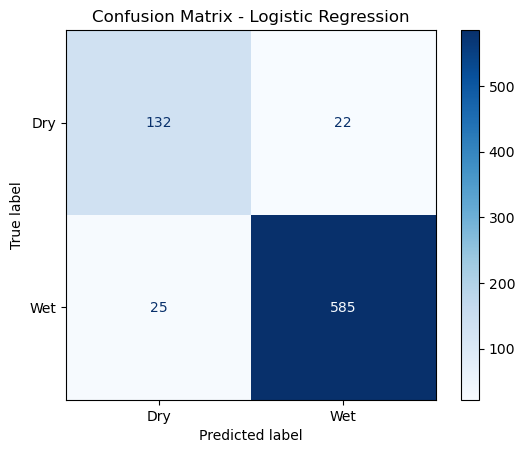

In [15]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dry', 'Wet'])
disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [16]:
# Make feature importances table (coefficients)
feature_cols = X_train.columns.tolist()

coefficients = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": LR_model.coef_[0]
})

# Sort by absolute value to see most important features
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

print(coefficients[['Feature', 'Coefficient']].to_string(index=False))

           Feature  Coefficient
        Out-degree     4.140090
     wetdry_status     3.454425
             Slope    -2.998770
     aspect_se_pct     2.593444
     aspect_ne_pct    -2.449138
               sph     2.433181
             rhmin     2.068056
             rhmax    -1.743166
       elev_min_cm    -1.539184
         curv_mean     1.477246
      slp_mean_pct     1.477246
              srad     1.469000
              prcp     1.234612
       MaxDepth_cm    -1.160305
          FromNode     1.125374
    elev_median_cm    -1.112571
      elev_mean_cm    -0.950543
            ToNode     0.903940
              tmin    -0.895311
         In-degree     0.819464
       elev_max_cm     0.770516
                vp     0.760732
                ws     0.755724
          AreaSqKm     0.647344
    slp_median_pct     0.495165
       curv_median     0.495165
   MaxDepth_Censor    -0.478817
         TotDASqKm     0.468160
         etalfalfa    -0.441093
MaxDepth_Threshold     0.210232
        

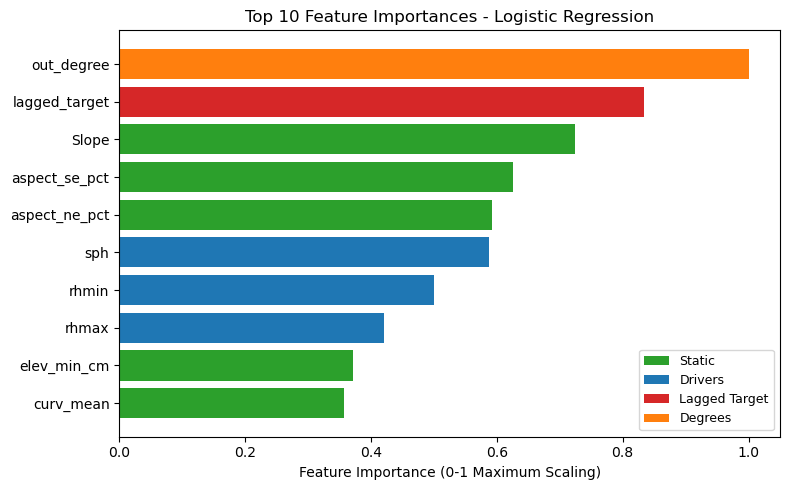

In [17]:
# Rename features for visualization
importance = coefficients[['Feature', 'Abs_Coefficient']].copy()
importance['Feature'] = importance['Feature'].replace({
    'Out-degree': 'out_degree',
    'In-degree': 'in_degree',
    'wetdry_status': 'lagged_target',
})

# Scale to 0-1
importance['Importance'] = importance['Abs_Coefficient'] / importance['Abs_Coefficient'].max()

# Color-code feature importances by category (consistent across notebooks)
from matplotlib.patches import Patch

FEATURE_CATEGORIES = {
    'lagged_target': 'Lagged Target',
    'in_degree': 'Degrees',
    'out_degree': 'Degrees',
}
for v in ['tmax', 'tmin', 'srad', 'prcp', 'vp', 'ws',
          'etgrass', 'etalfalfa', 'rhmax', 'rhmin', 'sph']:
    FEATURE_CATEGORIES[v] = 'Drivers'
for v in ['ArbolateSu', 'AreaSqKm', 'TotDASqKm', 'Slope', 'LengthKM',
          'FromNode', 'ToNode',
          'aspect_ne_pct', 'aspect_nw_pct', 'aspect_se_pct', 'aspect_sw_pct',
          'curv_mean', 'curv_median',
          'elev_max_cm', 'elev_mean_cm', 'elev_median_cm', 'elev_min_cm',
          'slp_mean_pct', 'slp_median_pct']:
    FEATURE_CATEGORIES[v] = 'Static'
for v in ['MaxDepth_cm', 'MaxDepth_Threshold', 'MaxDepth_Censor']:
    FEATURE_CATEGORIES[v] = 'Other Obs'

CATEGORY_COLORS = {
    'Lagged Target': '#d62728',  # red
    'Drivers':       '#1f77b4',  # blue
    'Static':        '#2ca02c',  # green
    'Degrees':       '#ff7f0e',  # orange
    'Other Obs':     '#9467bd',  # purple
    'Other':         '#7f7f7f',  # gray
}

def feature_color(name):
    return CATEGORY_COLORS[FEATURE_CATEGORIES.get(name, 'Other')]

def add_category_legend(ax, features):
    seen = []
    for f in features:
        cat = FEATURE_CATEGORIES.get(f, 'Other')
        if cat not in seen:
            seen.append(cat)
    handles = [Patch(facecolor=CATEGORY_COLORS[c], label=c) for c in seen]
    ax.legend(handles=handles, loc='lower right', fontsize=9, frameon=True)

# Plot top 10
top10 = importance.head(10)
features_top = top10['Feature'][::-1].tolist()
values_top   = top10['Importance'][::-1].tolist()
bar_colors   = [feature_color(f) for f in features_top]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(features_top, values_top, color=bar_colors)
ax.set_xlabel('Feature Importance (0-1 Maximum Scaling)')
ax.set_title('Top 10 Feature Importances - Logistic Regression')
add_category_legend(ax, features_top)
plt.tight_layout()
plt.show()

## Comparison Across Split Strategies

In [18]:
# Train and evaluate Logistic Regression with each split strategy
# Stream order columns excluded from features — saved separately for post-hoc evaluation
drop_cols = ['NHDPlusID', 'SiteIDCode', 'Date',
             'StreamOrde', 'FCode', 'n_discharge', 'n_water_presence', 'has_data']
splits = {
    'Random': random_split(central_df),
    'Temporal': temporal_split(central_df),
    'Site-Based': site_split(central_df),
}

split_data = {}
split_orders = {}  # test-set stream orders per split, for post-hoc evaluation
results = []

for name, (X_tr, X_te, y_tr, y_te) in splits.items():
    orders_te = X_te['StreamOrde'].values  # save before dropping

    X_tr = X_tr.drop(drop_cols, axis=1, errors='ignore')
    X_te = X_te.drop(drop_cols, axis=1, errors='ignore')

    # Scale
    scaler_split = StandardScaler()
    X_tr_scaled = scaler_split.fit_transform(X_tr)
    X_te_scaled = scaler_split.transform(X_te)

    # ADASYN
    adasyn = ADASYN(random_state=42)
    X_tr_res, y_tr_res = adasyn.fit_resample(X_tr_scaled, y_tr)

    # Train
    model = LogisticRegression(max_iter=3000, random_state=42)
    model.fit(X_tr_res, y_tr_res)

    # Predict
    y_pred = model.predict(X_te_scaled)

    split_data[name] = (y_te, y_pred)
    split_orders[name] = orders_te
    results.append({
        'Split': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
    })

# Display metrics table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

     Split  Accuracy  ROC-AUC       F1
    Random  0.954373 0.968041 0.972093
  Temporal  0.938482 0.908080 0.961380
Site-Based  0.796902 0.719290 0.862471


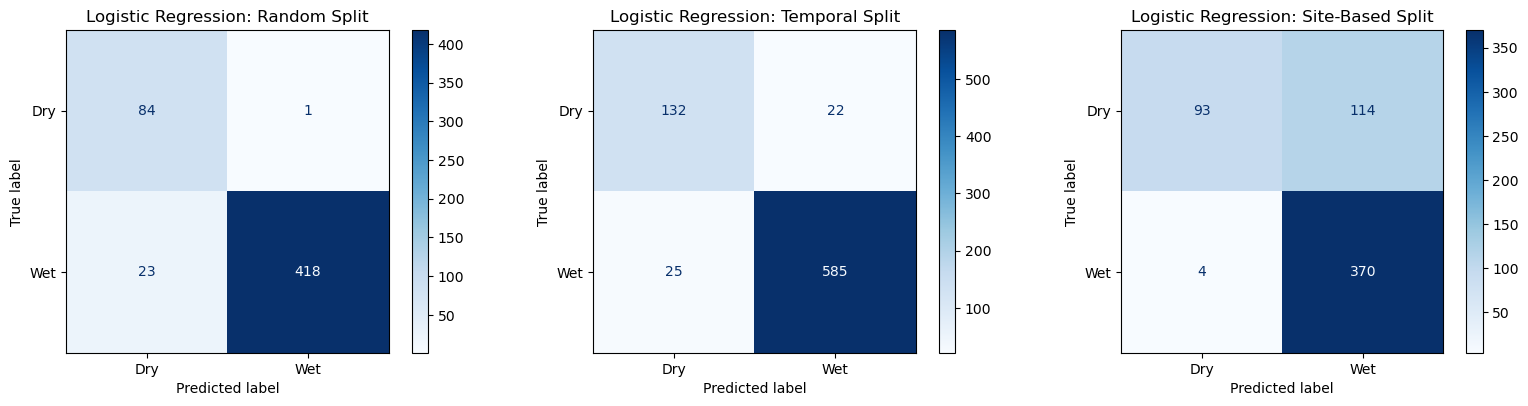


Random Split
              precision    recall  f1-score   support

         Dry      0.785     0.988     0.875        85
         Wet      0.998     0.948     0.972       441

    accuracy                          0.954       526
   macro avg      0.891     0.968     0.924       526
weighted avg      0.963     0.954     0.956       526


Temporal Split
              precision    recall  f1-score   support

         Dry      0.841     0.857     0.849       154
         Wet      0.964     0.959     0.961       610

    accuracy                          0.938       764
   macro avg      0.902     0.908     0.905       764
weighted avg      0.939     0.938     0.939       764


Site-Based Split
              precision    recall  f1-score   support

         Dry      0.959     0.449     0.612       207
         Wet      0.764     0.989     0.862       374

    accuracy                          0.797       581
   macro avg      0.862     0.719     0.737       581
weighted avg      0.834   

In [19]:
# Confusion matrices and classification reports
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, (y_te, y_p)) in zip(axes, split_data.items()):
    cm = confusion_matrix(y_te, y_p, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dry', 'Wet'])
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    ax.set_title(f'Logistic Regression: {name} Split')

plt.tight_layout()
plt.show()

for name, (y_te, y_p) in split_data.items():
    print(f"\n{'='*50}")
    print(f"{name} Split")
    print('='*50)
    print(classification_report(y_te, y_p, target_names=['Dry', 'Wet'], digits=3))

## Stream Order Comparison

This section evaluates model performance broken down by NHD stream order (1, 2, or 3). Stream order columns (`StreamOrde`, `FCode`, `n_discharge`, `n_water_presence`, `has_data`) are excluded from training features and used only here for grouping test-set predictions. Order 1 streams are the smallest headwaters; order 3 are larger downstream segments.

In [20]:
order_values = [1, 2, 3]

for split_name, (y_te, y_pred) in split_data.items():
    orders = split_orders[split_name]
    print(f"\n{'='*55}")
    print(f"Stream Order Breakdown — {split_name} Split")
    print('='*55)

    rows = []
    for order in order_values:
        mask = orders == order
        if mask.sum() == 0:
            continue
        yt = np.array(y_te)[mask]
        yp = y_pred[mask]
        rows.append({
            'Order': order,
            'N': int(mask.sum()),
            'Accuracy': accuracy_score(yt, yp),
            'ROC-AUC': roc_auc_score(yt, yp) if len(np.unique(yt)) > 1 else float('nan'),
            'F1': f1_score(yt, yp),
        })

    order_df = pd.DataFrame(rows)
    print(order_df.to_string(index=False))


Stream Order Breakdown — Random Split
 Order   N  Accuracy  ROC-AUC       F1
     1 262  0.942748 0.965753 0.964539
     2 164  0.981707 0.969197 0.989474
     3 100  0.940000 0.962025 0.960526

Stream Order Breakdown — Temporal Split
 Order   N  Accuracy  ROC-AUC       F1
     1 392  0.941327 0.910924 0.960684
     2 235  0.953191 0.927105 0.973105
     3 137  0.905109 0.888340 0.941704

Stream Order Breakdown — Site-Based Split
 Order   N  Accuracy  ROC-AUC       F1
     1 343  0.967930  0.95677 0.977505
     2 120  0.108333  0.50000 0.195489
     3 118  1.000000      NaN 1.000000


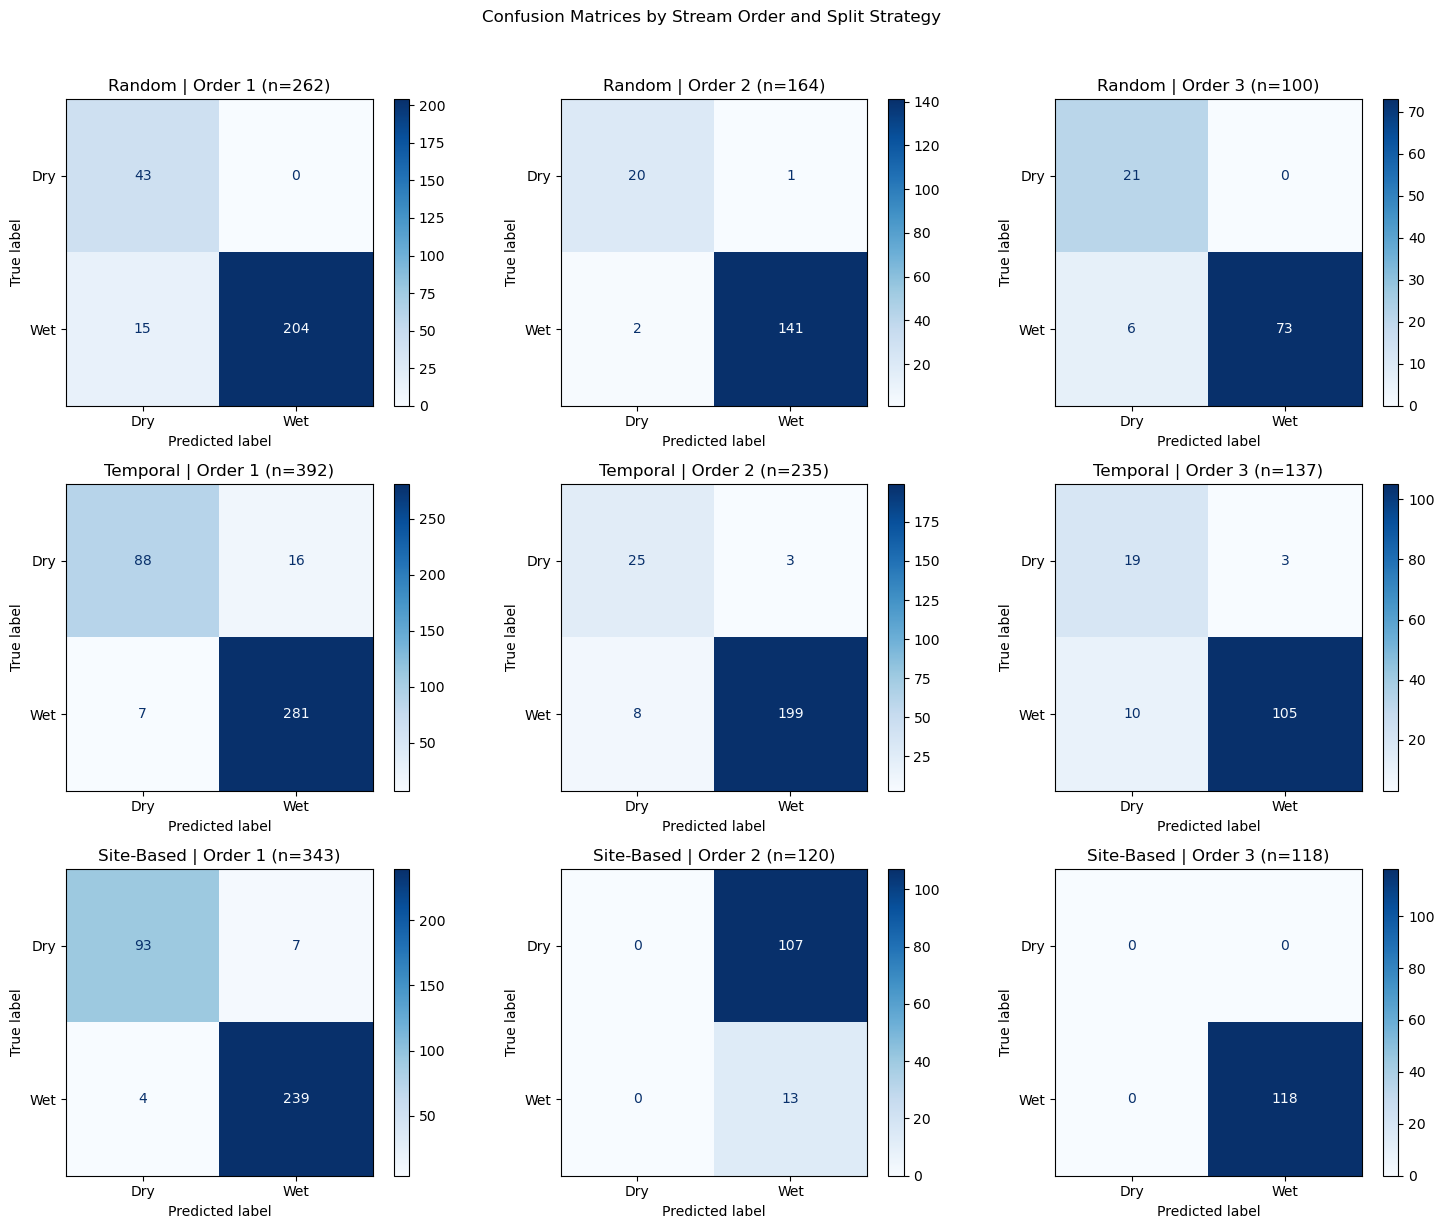

In [21]:
order_values = [1, 2, 3]
n_splits = len(split_data)
n_orders = len(order_values)

fig, axes = plt.subplots(n_splits, n_orders, figsize=(5 * n_orders, 4 * n_splits))

for row_idx, (split_name, (y_te, y_pred)) in enumerate(split_data.items()):
    orders = split_orders[split_name]
    for col_idx, order in enumerate(order_values):
        ax = axes[row_idx][col_idx]
        mask = orders == order
        if mask.sum() == 0:
            ax.set_visible(False)
            continue
        yt = np.array(y_te)[mask]
        yp = y_pred[mask]
        cm = confusion_matrix(yt, yp, labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dry', 'Wet'])
        disp.plot(cmap='Blues', values_format='d', ax=ax)
        ax.set_title(f'{split_name} | Order {order} (n={mask.sum()})')

plt.suptitle('Confusion Matrices by Stream Order and Split Strategy', y=1.02)
plt.tight_layout()
plt.show()

## Inference

In [22]:
def predict_site_date(model, scaler, central_df, feature_cols, site_id, date, days_ahead=3):
    """
    Predict wet/dry status for a given site on day n+days_ahead given its wet/dry status and features on day n.
    
    Parameters:
    -----------
    model : LogisticRegression
        Trained logistic regression model
    scaler : StandardScaler
        Fitted scaler for feature normalization
    central_df : pd.DataFrame
        Complete dataset with all features
    feature_cols : list
        List of feature column names used in training
    site_id : str
        Site identifier (e.g., "HoboSite100")
    date : str
        Date in format "YYYY-MM-DD"
    
    Returns:
    --------
    str : Prediction result with probability
    """
    date = pd.to_datetime(date)
    site_id = str(site_id)
    
    row = central_df[(central_df["SiteIDCode"] == site_id) & (central_df["Date"] == date)]
    
    if row.empty:
        return f"No data found for Site {site_id} on {date.date()}"
    
    Xq = row[feature_cols]
    Xq_scaled = scaler.transform(Xq)
    
    pred_class = model.predict(Xq_scaled)
    pred_prob = model.predict_proba(Xq_scaled)[:, 1]
    
    return f"Site {site_id} on {(date + pd.Timedelta(days=days_ahead)).date()} (predicted from {date.date()}): {'DRY' if pred_class == 0 else 'WET'}, (P(wet)={pred_prob[0]:.4f})"

In [23]:
# Example inference
predict_site_date(
    model=LR_model,
    scaler=scaler,
    central_df=central_df,
    feature_cols=feature_cols,
    site_id="HoboSite100",
    date="2020-10-22"
)

'Site HoboSite100 on 2020-10-25 (predicted from 2020-10-22): DRY, (P(wet)=0.0000)'